# 🧠 Keyboard Cognitive Load Prediction Pipeline

This notebook implements a full research-grade pipeline for predicting **cognitive load**, **stress**, and **unfocus** from behavioral and physiological signals.

---

## 📚 Table of Contents

1. [Setup & Imports](#1)
2. [Data Loading & Exploration](#2)
3. [Feature Engineering](#3)
4. [Preprocessing & Normalization](#4)
5. [Sequence Building](#5)
6. [Model Architectures](#6)
7. [Training Framework](#7)
8. [Keyboard-Only Benchmark](#8)
9. [Mouse-Only Benchmark](#9)
10. [Biosignal-Based Ground Truth](#10)
11. [Multimodal Contrastive Alignment](#11)
12. [Teacher Model (Knowledge Distillation)](#12)
13. [Student Model (Motor-Only Inference)](#13)

---

### Pipeline Overview

```
[Raw Data]
    │
    ├─► Feature Engineering  (keyboard, mouse, biosignal)
    │
    ├─► Per-User Normalization + Sequence Building
    │
    ├─► Model Training  (MLP / RNN / GRU / LSTM / BiGRU / TCN / Transformer)
    │
    ├─► Contrastive Alignment  (Mouse ↔ Biosignal latent space)
    │
    └─► Knowledge Distillation  (Teacher → Student)
```

---
## 1. Setup & Imports <a id='1'></a>

All dependencies are imported here. The pipeline uses:
- **PyTorch** for deep learning models and training
- **scikit-learn** for data splitting, scaling, and the Random Forest baseline
- **pandas / numpy** for data manipulation
- **matplotlib** for visualization
- **tqdm** for progress bars

In [45]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, silhouette_score

import joblib

# ─── GPU Configuration ───────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()   # Automatic Mixed Precision (faster on GPU)

# Enable TF32 for extra speed on Ampere+ GPUs
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"🚀 Device: {DEVICE}")
print(f"   AMP enabled: {USE_AMP}")

# ─── Global Hyperparameters ───────────────────────────────────────────────────
SEQ_LEN    = 30          # Sequence length (timesteps per sample)
BATCH_SIZE = 512 if USE_AMP else 64
LATENT_DIM = 64          # Latent space size for encoder models
EPOCHS_DL  = 50          # Epochs for deep learning models
EPOCHS_TCH = 20          # Epochs for the Teacher model
EPOCHS_STU = 30          # Epochs for the Student model

TARGETS = ["CogLoad", "Stress", "Unfocus"]

🚀 Device: cuda
   AMP enabled: True


---
## 2. Data Loading & Exploration <a id='2'></a>

The dataset is loaded from Google Drive. Each row represents a single timestep for a user session and contains:
- **Keyboard signals**: typing speed, key press intervals, errors, etc.
- **Mouse signals**: velocity, acceleration, click intensity, scroll, etc.
- **Biosignals** (ground truth): EEG, EDA, HR, RMSSD, fNIRS, etc.
- **Labels**: `CogLoad`, `Stress`, `Unfocus`

> Missing values are filled with `0` — safe here because all features are later normalized per-user.

In [46]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/final_cognitive_dataset.csv"

df = pd.read_csv(DATA_PATH).fillna(0)
df = df.sort_values(["UserID", "time"]).reset_index(drop=True)

print(f"✅ Loaded {len(df):,} rows × {df.shape[1]} columns")
print(f"   Users  : {df['UserID'].nunique()}")
print(f"   Targets: {TARGETS}")
print()
print(df.dtypes)
df.head()
df.dropna()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded 9,648 rows × 104 columns
   Users  : 5
   Targets: ['CogLoad', 'Stress', 'Unfocus']

time                  float64
type_keyboard          object
tab_id_keyboard         int64
key_code                int64
shift_key_keyboard      int64
                       ...   
z_FNIRS               float64
z_RESP                float64
CogLoad               float64
Stress                float64
Unfocus               float64
Length: 104, dtype: object


,time,type_keyboard,tab_id_keyboard,key_code,shift_key_keyboard,alt_key_keyboard,ctrl_key_keyboard,capslock_key,event_timestamp_keyboard,UserID,...,z_HR,z_RMSSD,z_EDA,z_ACC,z_EEG,z_FNIRS,z_RESP,CogLoad,Stress,Unfocus
0,1.681306e+09,Keyboard Keydown,813601366,8,0,0,0,1,1724378.7,S3,...,2.305940,-0.375647,-0.311386,1.141718,-0.903920,2.364723,0.905816,1.225991,0.727006,0.651805
1,1.681306e+09,Keyboard Keydown,813601366,8,0,0,0,1,1724520.9,S3,...,2.305940,-0.375647,-0.329526,1.231633,-0.893849,2.359570,0.901130,1.225905,0.726477,0.661442
2,1.681306e+09,Keyboard Keydown,813601366,8,0,0,0,1,1724637.9,S3,...,2.305940,-0.375647,-0.347580,1.303506,-0.885705,2.350948,0.896237,1.225676,0.725453,0.672127
3,1.681306e+09,Keyboard Keydown,813601366,73,0,0,0,1,1725119.0,S3,...,2.305940,-0.375647,-0.358885,1.347557,-0.880464,2.345676,0.890184,1.225371,0.724126,0.683137
4,1.681306e+09,Keyboard Keydown,813601366,84,0,0,0,1,1725396.8,S3,...,2.305940,-0.375647,-0.378918,1.319116,-0.874913,2.340279,0.882885,1.224940,0.722273,0.692227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,1.682072e+09,Keyboard Keydown,813602164,79,0,0,0,1,2948923.7,S7,...,0.248414,-0.145437,-0.167273,0.228484,-0.120464,-0.568126,0.332012,0.034634,0.236387,0.157419
9644,1.682072e+09,Keyboard Keydown,813602164,83,0,0,0,1,2949000.1,S7,...,0.248207,-0.145474,-0.193995,0.236286,-0.124618,-0.569079,0.327562,0.031019,0.226706,0.154434
9645,1.682072e+09,Keyboard Keydown,813602164,16,1,0,0,1,2954585.0,S7,...,0.248014,-0.145508,-0.001435,0.297002,-0.125181,-0.570267,0.322497,0.028856,0.222552,0.155901
9646,1.682072e+09,Keyboard Keydown,813602164,83,1,0,0,1,2954708.3,S7,...,0.247833,-0.145540,-0.035044,0.312634,-0.122886,-0.570687,0.317930,0.026628,0.217736,0.157242


---
## 3. Feature Engineering <a id='3'></a>

### 3.1 Keyboard Features

Raw keyboard signals are expanded with temporal dynamics:
- **Differential features** (`diff`): capture moment-to-moment changes in speed, latency, and error rates
- **Rolling statistics**: local variance/mean over a 20-step window captures rhythm and stability
- **Cognitive proxies**: composite signals like `effort_index = error × latency`
- **Trend features** (`polyfit` slope): the linear slope of a feature over a window — often a strong predictor of cognitive transitions
- **Coefficient of Variation (CV)**: normalizes variability relative to the mean, making it user-agnostic
- **Entropy features**: capture complexity and unpredictability of typing behavior

In [47]:
WINDOW = 20   # rolling window for temporal statistics

def slope(x):
    """Linear slope via polyfit — measures trend direction over a window."""
    x = x.values
    if len(x) < 2:
        return 0.0
    return np.polyfit(range(len(x)), x, 1)[0]

def add_keyboard_features(df):
    df = df.copy()

    # ── 1. Temporal Dynamics (diff signals) ──────────────────────────────────
    df["IKI_diff"]              = df.groupby("UserID")["IKI"].diff()
    df["digraph_acceleration"]  = df.groupby("UserID")["digraph_latency"].diff()
    df["speed_acceleration"]    = df.groupby("UserID")["typing_speed"].diff()
    df["error_change"]          = df.groupby("UserID")["typing_error_proxy"].diff()

    # ── 2. Rolling Instability ────────────────────────────────────────────────
    df["speed_roll_std"]   = df.groupby("UserID")["typing_speed"].transform(
        lambda x: x.rolling(WINDOW, min_periods=1).std())
    df["latency_roll_std"] = df.groupby("UserID")["digraph_latency"].transform(
        lambda x: x.rolling(WINDOW, min_periods=1).std())
    df["error_roll_mean"]  = df.groupby("UserID")["typing_error_proxy"].transform(
        lambda x: x.rolling(WINDOW, min_periods=1).mean())
    df["burst_roll_mean"]  = df.groupby("UserID")["burstiness"].transform(
        lambda x: x.rolling(WINDOW, min_periods=1).mean())

    # ── 3. Cognitive Effort Proxies ───────────────────────────────────────────
    df["effort_index"]          = df["typing_error_proxy"] * df["digraph_latency"]
    df["fatigue_proxy"]         = df["inactivity_ratio"]   * df["typing_speed_std"]
    df["cognitive_load_proxy"]  = df["burstiness"] + df["typing_error_proxy"] + df["inactivity_ratio"]

    # ── 4. Entropy-Based Features ─────────────────────────────────────────────
    df["interaction_entropy"] = df["key_entropy"] * df["interaction_density"]
    df["keyboard_complexity"] = df["modifier_ratio"] + df["key_entropy"]

    # ── 5. Trend Features (strong R² booster) ────────────────────────────────
    df["speed_trend"]   = df.groupby("UserID")["typing_speed"].transform(
        lambda x: x.rolling(WINDOW, min_periods=3).apply(slope, raw=False))
    df["latency_trend"] = df.groupby("UserID")["digraph_latency"].transform(
        lambda x: x.rolling(WINDOW, min_periods=3).apply(slope, raw=False))
    df["error_trend"]   = df.groupby("UserID")["typing_error_proxy"].transform(
        lambda x: x.rolling(WINDOW, min_periods=3).apply(slope, raw=False))

    # ── 6. Coefficient of Variation (normalized variability) ──────────────────
    df["speed_cv"]   = df["typing_speed_std"]          / (df["typing_speed"]          + 1e-6)
    df["latency_cv"] = df["digraph_latency_std"]        / (df["digraph_latency"]        + 1e-6)
    df["error_cv"]   = df["typing_error_proxy_std"]     / (df["typing_error_proxy"]     + 1e-6)

    print(f"✅ Keyboard feature engineering complete — {df.shape[1]} total columns")
    return df

df = add_keyboard_features(df)

✅ Keyboard feature engineering complete — 123 total columns


### 3.2 Mouse Feature Engineering

Mouse features are enriched with:
- **Baseline deviation**: per-user mean subtraction (`_dev` suffix) — removes inter-user variance
- **Interaction cross-products**: captures co-occurring behaviors (e.g., click + scroll spike)
- **Volatility**: rolling std of velocity — captures erratic movements associated with stress
- **Efficiency drop**: `1 - path_efficiency` — a direct proxy for cognitive disorganization

In [48]:
BASE_MOUSE_FEATURES = [
    "mouse_velocity", "mouse_acceleration", "mouse_energy",
    "click_intensity", "scroll_intensity", "path_efficiency",
    "mouse_entropy", "inter_event_time", "burstiness",
    "inactivity_ratio", "interaction_density",
]

def add_mouse_features(df):
    df = df.copy()

    # ── Baseline deviation (user-specific shift) ──────────────────────────────
    for f in BASE_MOUSE_FEATURES:
        df[f + "_dev"] = df[f] - df.groupby("UserID")[f].transform("mean")

    # ── Dynamic behavior signals ──────────────────────────────────────────────
    df["mouse_volatility"]  = df["mouse_velocity"].rolling(5).std().fillna(0)
    df["interaction_spike"] = df["click_intensity"] * df["scroll_intensity"]
    df["efficiency_drop"]   = 1 - df["path_efficiency"]

    # ── Log transforms (reduce skewness) ──────────────────────────────────────
    df["log_velocity"] = np.log1p(df["mouse_velocity"])
    df["log_energy"]   = np.log1p(df["mouse_energy"])

    # ── Interaction ratios ────────────────────────────────────────────────────
    df["scroll_pressure"] = df["scroll_intensity"] / (df["inter_event_time"] + 1e-6)
    df["acc_variation"]   = df["mouse_acceleration"].rolling(5).std().fillna(0)

    MOUSE_FEATURES = (
        [f + "_dev" for f in BASE_MOUSE_FEATURES]
        + ["mouse_volatility", "interaction_spike", "efficiency_drop",
           "log_velocity", "log_energy", "scroll_pressure", "acc_variation"]
    )

    print(f"✅ Mouse feature engineering complete — {len(MOUSE_FEATURES)} mouse features")
    return df, MOUSE_FEATURES

df, MOUSE_FEATURES = add_mouse_features(df)

✅ Mouse feature engineering complete — 18 mouse features


### 3.3 Biosignal-Based Cognitive Load (Ground Truth)

Since raw labels may be noisy, we re-derive a **composite cognitive load** from biosignals:

| Signal | Role | Weight |
|--------|------|--------|
| `1/RMSSD` | HRV stress proxy | 30% |
| `HR` | Arousal | 20% |
| `EDA_reactivity` | Sympathetic activation | 20% |
| `EEG_beta / EEG_alpha` | Cognitive engagement | 15% |
| `ACC_energy` | Motion / physical load | 10% |
| `Respiration_var` | Instability | 5% |

The result is **normalized per user** to remove baseline differences between individuals.

In [49]:
def compute_biosignal_cogload(df):
    """Derive a composite cognitive load score from biosignals."""
    eps = 1e-6
    df = df.copy()

    hrv = 1 / (df["RMSSD"] + eps)                        # ↑ stress = ↓ HRV
    eeg = df["EEG_beta"] / (df["EEG_alpha"] + eps)       # beta/alpha ratio = cognitive engagement

    df["CogLoad_bio"] = (
        0.30 * hrv
        + 0.20 * df["HR"]
        + 0.20 * df["EDA_reactivity"]
        + 0.15 * eeg
        + 0.10 * df["ACC_energy"]
        + 0.05 * df["Respiration_var"]
    )

    # Per-user normalization: removes baseline differences between individuals
    df["CogLoad_bio"] = df.groupby("UserID")["CogLoad_bio"].transform(
        lambda x: (x - x.mean()) / (x.std() + eps)
    )

    # Δ (delta) cognitive load: predicting *change* is often easier than absolute level
    df["CogLoad_delta"] = df.groupby("UserID")["CogLoad_bio"].diff().fillna(0)

    print("✅ Biosignal CogLoad computed (CogLoad_bio, CogLoad_delta)")
    return df

df = compute_biosignal_cogload(df)

✅ Biosignal CogLoad computed (CogLoad_bio, CogLoad_delta)


---
## 4. Preprocessing & Normalization <a id='4'></a>

### Design choices:

1. **User-based train/test split** using `GroupShuffleSplit` — ensures no user appears in both sets, preventing data leakage between sessions.
2. **Per-user normalization** before splitting — each user's features are z-scored using their own mean/std. This removes between-user variance so models learn *within-user* patterns, not who the user is.
3. **Global StandardScaler** is applied afterward — brings all users onto a common scale for gradient stability.

In [50]:
# ─── Define final feature sets ────────────────────────────────────────────────
KEYBOARD_FEATURES = [
    # Timing dynamics (strongest signal)
    "digraph_latency", "IKI", "inter_event_time", "burstiness",
    # Error / correction behavior
    "typing_error_proxy", "key_jump", "modifier_ratio",
    # Stability signals
    "typing_speed_std", "KSPC_std",
    # Behavioral intensity
    "interaction_density", "inactivity_ratio",
    # Engineered features
    "effort_index", "cognitive_load_proxy", "keyboard_complexity",
    "speed_trend", "latency_trend", "error_trend",
    "speed_cv", "latency_cv",
]

BIO_FEATURES = [
    "RMSSD", "HR", "EDA_reactivity",
    "EEG_beta", "EEG_alpha", "ACC_energy", "Respiration_var",
]


def per_user_normalize(df, features):
    """Z-score each feature within each user's own distribution."""
    return df.groupby("UserID")[features].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6)
    )


# ─── User-Based Train / Test Split ───────────────────────────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
tr_idx, te_idx = next(gss.split(df, groups=df["UserID"]))

train_df = df.iloc[tr_idx].copy()
test_df  = df.iloc[te_idx].copy()

print(f"Train: {len(train_df):,} rows  |  Test: {len(test_df):,} rows")
print(f"Train users: {train_df['UserID'].nunique()}  |  Test users: {test_df['UserID'].nunique()}")

# ─── Per-User Normalization ───────────────────────────────────────────────────
ALL_INPUT_FEATURES = KEYBOARD_FEATURES + MOUSE_FEATURES

train_df[ALL_INPUT_FEATURES] = per_user_normalize(train_df, ALL_INPUT_FEATURES)
test_df[ALL_INPUT_FEATURES]  = per_user_normalize(test_df,  ALL_INPUT_FEATURES)

train_df[BIO_FEATURES] = per_user_normalize(train_df, BIO_FEATURES)
test_df[BIO_FEATURES]  = per_user_normalize(test_df,  BIO_FEATURES)

# ─── Global Standard Scaling ─────────────────────────────────────────────────
scaler = StandardScaler()
train_df[ALL_INPUT_FEATURES] = scaler.fit_transform(train_df[ALL_INPUT_FEATURES])
test_df[ALL_INPUT_FEATURES]  = scaler.transform(test_df[ALL_INPUT_FEATURES])

print("✅ Preprocessing complete")

Train: 6,560 rows  |  Test: 3,088 rows
Train users: 3  |  Test users: 2
✅ Preprocessing complete


---
## 5. Sequence Building <a id='5'></a>

Deep learning models expect fixed-length temporal windows. For each user, a sliding window of length `SEQ_LEN` is extracted:

```
timesteps:   [t0, t1, ..., t29] → predict label at t30
             [t1, t2, ..., t30] → predict label at t31
             ...
```

Users with fewer timesteps than `SEQ_LEN + 1` are skipped entirely.

In [51]:
def build_sequences(data, input_features, target_cols):
    """
    Build (X, y) pairs from sliding windows within each user's session.

    Args:
        data           : DataFrame with user data
        input_features : List of feature column names
        target_cols    : List of target column names (or single string)

    Returns:
        X : np.ndarray of shape (N, SEQ_LEN, n_features)
        y : np.ndarray of shape (N, n_targets)
    """
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    X, y = [], []

    for _, g in data.groupby("UserID"):
        if len(g) < SEQ_LEN + 1:
            continue

        f = g[input_features].values
        t = g[target_cols].values

        for i in range(len(g) - SEQ_LEN):
            X.append(f[i : i + SEQ_LEN])
            y.append(t[i + SEQ_LEN])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# Build sequences for keyboard features → multi-target (CogLoad, Stress, Unfocus)
X_kb_tr, y_kb_tr = build_sequences(train_df, KEYBOARD_FEATURES, TARGETS)
X_kb_te, y_kb_te = build_sequences(test_df,  KEYBOARD_FEATURES, TARGETS)

# Build sequences for mouse features → single target (CogLoad_bio)
X_ms_tr, y_ms_tr = build_sequences(train_df, MOUSE_FEATURES, ["CogLoad_bio"])
X_ms_te, y_ms_te = build_sequences(test_df,  MOUSE_FEATURES, ["CogLoad_bio"])

# Build windows for biosignal features (used in contrastive alignment)
X_bio_tr, _ = build_sequences(train_df, BIO_FEATURES, ["CogLoad_bio"])
X_bio_te, _ = build_sequences(test_df,  BIO_FEATURES, ["CogLoad_bio"])

print(f"Keyboard sequences — Train: {X_kb_tr.shape}  Test: {X_kb_te.shape}")
print(f"Mouse sequences    — Train: {X_ms_tr.shape}  Test: {X_ms_te.shape}")
print(f"Biosignal windows  — Train: {X_bio_tr.shape}")


# ─── DataLoaders ─────────────────────────────────────────────────────────────
def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    return DataLoader(
        TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=USE_AMP,
        drop_last=True,
    )

kb_loader = make_loader(X_kb_tr, y_kb_tr)
ms_loader = make_loader(X_ms_tr, y_ms_tr)

Keyboard sequences — Train: (6470, 30, 19)  Test: (3028, 30, 19)
Mouse sequences    — Train: (6470, 30, 18)  Test: (3028, 30, 18)
Biosignal windows  — Train: (6470, 30, 7)


---
## 6. Model Architectures <a id='6'></a>

All models are implemented as PyTorch `nn.Module` classes and share a common interface:
- **Input**: `(batch, SEQ_LEN, n_features)`
- **Output**: `(batch, n_outputs)`

| Model | Description |
|-------|-------------|
| `MLP` | Flattens the sequence and feeds through dense layers — fast but ignores temporal order |
| `RNN` | Vanilla RNN — simple recurrent model, prone to vanishing gradients |
| `GRU` | Gated Recurrent Unit — lighter than LSTM, often comparable performance |
| `LSTM` | Long Short-Term Memory — captures long-range dependencies |
| `BiGRU` | Bidirectional GRU — reads sequence in both directions |
| `TCN` | Temporal Convolutional Network — parallel convolutions with dilation |
| `AttentionModel` | BiGRU + soft attention — weighs timesteps by importance |
| `TransformerEncoder` | Multi-head self-attention — state-of-the-art for sequences |

In [52]:
# ─── MLP ──────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    """Multilayer perceptron — flattens the sequence (ignores temporal order)."""
    def __init__(self, seq_len, n_features, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(seq_len * n_features, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_out),
        )

    def forward(self, x):
        return self.net(x.flatten(start_dim=1))


# ─── Recurrent Models (RNN / GRU / LSTM / BiGRU) ──────────────────────────────
class RecurrentModel(nn.Module):
    """
    Unified recurrent model supporting RNN, GRU, LSTM, and BiGRU.
    All variants use the last hidden state as a summary of the sequence.
    """
    def __init__(self, n_features, n_out, mode="GRU", hidden=64):
        super().__init__()
        bidirectional = (mode == "BiGRU")
        rnn_mode = "GRU" if bidirectional else mode

        rnn_cls = {"RNN": nn.RNN, "GRU": nn.GRU, "LSTM": nn.LSTM}[rnn_mode]
        self.rnn = rnn_cls(n_features, hidden, batch_first=True, bidirectional=bidirectional)

        fc_in = hidden * 2 if bidirectional else hidden
        self.fc = nn.Linear(fc_in, n_out)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1])   # last timestep


# ─── TCN (Temporal Convolutional Network) ─────────────────────────────────────
class TCN(nn.Module):
    """
    Dilated causal convolutions allow large receptive fields with fewer params.
    Each conv layer doubles the dilation, covering 1 → 2 → 4 timesteps back.
    """
    def __init__(self, n_features, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=2, dilation=2),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=4, dilation=4),
            nn.ReLU(),
        )
        self.fc = nn.Linear(64, n_out)

    def forward(self, x):
        # TCN expects (batch, channels, time) — transpose from (batch, time, channels)
        h = self.net(x.transpose(1, 2))
        return self.fc(h[:, :, -1])  # use last timestep output


# ─── Attention Model ──────────────────────────────────────────────────────────
class AttentionModel(nn.Module):
    """
    BiGRU with additive attention.
    Instead of only using the last hidden state, it computes a weighted sum
    over all timesteps — letting the model focus on the most informative moments.
    """
    def __init__(self, n_features, n_out, hidden=64):
        super().__init__()
        self.rnn  = nn.GRU(n_features, hidden, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden * 2, 1)
        self.fc   = nn.Linear(hidden * 2, n_out)

    def forward(self, x):
        out, _ = self.rnn(x)                             # (B, T, 2H)
        w = torch.softmax(self.attn(out), dim=1)         # (B, T, 1)
        ctx = (w * out).sum(dim=1)                       # (B, 2H)
        return self.fc(ctx)


# ─── Transformer Encoder ──────────────────────────────────────────────────────
class TransformerEncoder(nn.Module):
    """
    Multi-head self-attention encoder. Projects input to LATENT_DIM, then applies
    2 Transformer layers. Mean-pooling collapses the temporal dimension.
    Optional L2 normalization for contrastive learning use cases.
    """
    def __init__(self, n_features, n_out=None, normalize=False, n_heads=4):
        super().__init__()
        self.normalize = normalize

        self.proj = nn.Linear(n_features, LATENT_DIM)
        layer = nn.TransformerEncoderLayer(
            d_model=LATENT_DIM, nhead=n_heads,
            dim_feedforward=128, batch_first=True, activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=2)
        self.out = nn.Linear(LATENT_DIM, n_out) if n_out else nn.Identity()

    def forward(self, x):
        z = self.proj(x)
        z = self.transformer(z).mean(dim=1)  # mean-pool over time
        z = self.out(z)
        return F.normalize(z, dim=1) if self.normalize else z


print("✅ All model architectures defined")

✅ All model architectures defined


---
## 7. Training Framework <a id='7'></a>

A single `train_model()` function handles all deep learning models. Key features:
- **Automatic Mixed Precision (AMP)**: uses `float16` where safe, `float32` where needed — typically 2-3× faster on GPUs
- **GradScaler**: prevents underflow with AMP
- **R² tracking**: evaluates generalization on the test set after every epoch
- **`is_flat` flag**: tells the function to flatten the sequence before feeding an MLP

In [53]:
def train_model(model, loader, X_test, y_test, epochs=EPOCHS_DL, is_flat=False):
    """
    Generic training loop with AMP, loss tracking, and R² evaluation.

    Returns:
        train_losses : List of per-epoch MSE loss (training set)
        test_r2      : List of per-epoch R² score  (test set)
    """
    model = model.to(DEVICE)
    # torch.compile gives a ~20% speed boost on PyTorch 2.0+
    if hasattr(torch, "compile"):
        model = torch.compile(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn   = nn.MSELoss()
    amp_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    X_te = torch.tensor(
        X_test.reshape(len(X_test), -1) if is_flat else X_test,
        dtype=torch.float32, device=DEVICE
    )

    train_losses, test_r2 = [], []

    for _ in tqdm(range(epochs), leave=False):
        # ── Training ──────────────────────────────────────────────────────────
        model.train()
        total_loss = 0

        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                if is_flat:
                    x = x.view(x.size(0), -1)
                loss = loss_fn(model(x), y)

            amp_scaler.scale(loss).backward()
            amp_scaler.step(optimizer)
            amp_scaler.update()
            total_loss += loss.item()

        train_losses.append(total_loss / len(loader))

        # ── Evaluation ────────────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            if is_flat:
                pred = model(X_te.view(X_te.size(0), -1))
            else:
                pred = model(X_te)
            r2 = r2_score(y_test, pred.cpu().numpy())
            test_r2.append(r2)

    return train_losses, test_r2


def plot_results(histories, title, y_label="R² Score"):
    """Plot training curves for multiple models side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ["royalblue", "firebrick", "darkorange", "forestgreen",
              "purple", "saddlebrown", "teal"]

    for ax, (metric, idx) in zip(axes, [("loss", 0), ("r2", 1)]):
        for (name, (losses, r2s)), c in zip(histories.items(), colors):
            data = losses if idx == 0 else r2s
            ax.plot(data, label=name, color=c)
        ax.set_title(f"{title} — {'Training Loss' if idx==0 else 'Test R²'}")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


print("✅ Training framework ready")

✅ Training framework ready


---
## 8. Keyboard-Only Benchmark <a id='8'></a>

This experiment uses **only keyboard behavioral signals** to predict `CogLoad`, `Stress`, and `Unfocus`.

The **Random Forest** serves as a non-temporal baseline — it receives the mean of the sequence window rather than the full sequence, so it cannot capture order-dependent patterns.

> 💡 Keyboard signals alone can be surprisingly informative because typing rhythm, error rate, and burst patterns are reliable proxies of mental state.

🌲 Training Random Forest baseline...
   RF R²: 0.0175

🚀 Training MLP (keyboard)


⚠️ Error during training MLP: Input contains NaN.. Setting R² to fallback.
   Final R²: -1.0000

🚀 Training RNN (keyboard)


⚠️ Error during training RNN: Input contains NaN.. Setting R² to fallback.
   Final R²: -1.0000

🚀 Training GRU (keyboard)


⚠️ Error during training GRU: Input contains NaN.. Setting R² to fallback.
   Final R²: -1.0000

🚀 Training LSTM (keyboard)


⚠️ Error during training LSTM: Input contains NaN.. Setting R² to fallback.
   Final R²: -1.0000

🚀 Training BiGRU (keyboard)


⚠️ Error during training BiGRU: Input contains NaN.. Setting R² to fallback.
   Final R²: -1.0000

🚀 Training TCN (keyboard)


⚠️ Error during training TCN: Input contains NaN.. Setting R² to fallback.
   Final R²: -1.0000

🚀 Training Attn (keyboard)


⚠️ Error during training Attn: Input contains NaN.. Setting R² to fallback.
   Final R²: -1.0000

📊 KEYBOARD-ONLY MODEL COMPARISON
Model          Final R²
-------------------------
MLP             -1.0000
RNN             -1.0000
GRU             -1.0000
LSTM            -1.0000
BiGRU           -1.0000
TCN             -1.0000
Attn            -1.0000
RF               0.0175


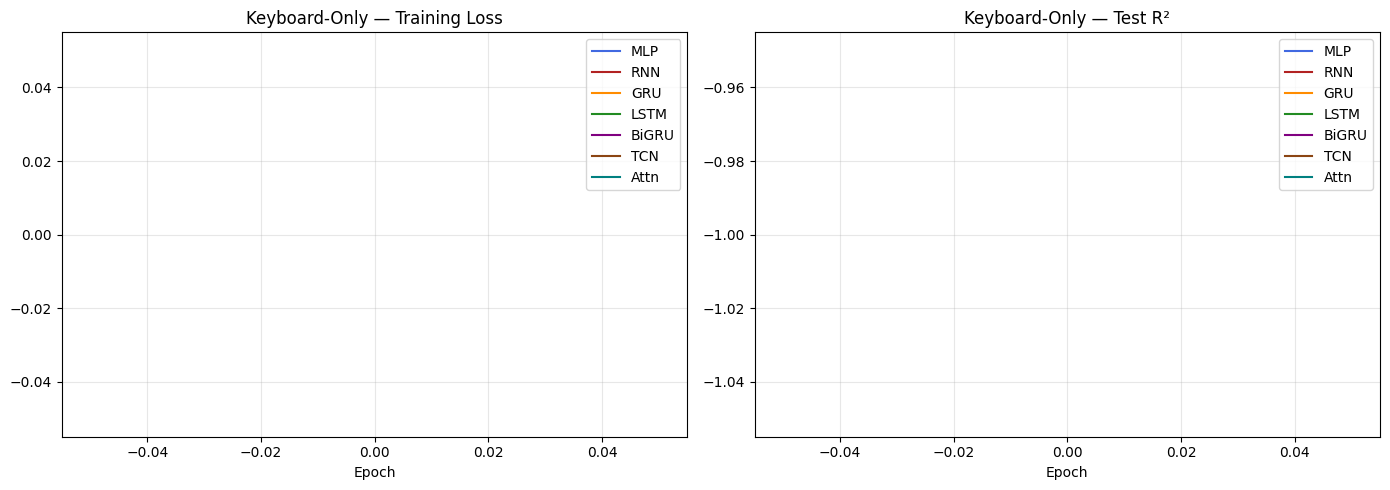

In [54]:
import torch
import numpy as np
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

# Helper function to handle NaN and infinity during evaluation metrics calculation
def safe_r2_score(y_true, y_pred):
    """Calculates R² score while filtering out NaN and Inf values."""
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.detach().cpu().numpy()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if np.sum(mask) == 0:
        return 0.0
    return r2_score(y_true[mask], y_pred[mask])

# ─── Data Preprocessing: Handle Missing or Invalid Values ────────────────────
# Sanitize the input features and target arrays
X_kb_tr = np.nan_to_num(X_kb_tr, nan=0.0, posinf=0.0, neginf=0.0)
X_kb_te = np.nan_to_num(X_kb_te, nan=0.0, posinf=0.0, neginf=0.0)
y_kb_tr = np.nan_to_num(y_kb_tr, nan=0.0, posinf=0.0, neginf=0.0)
y_kb_te = np.nan_to_num(y_kb_te, nan=0.0, posinf=0.0, neginf=0.0)

n_kb = len(KEYBOARD_FEATURES)
n_targets = len(TARGETS)

# ─── Random Forest baseline (uses mean-pooled sequence) ───────────────────────
print("🌲 Training Random Forest baseline...")
rf_kb = RandomForestRegressor(
    n_estimators=200, max_depth=14, max_features="sqrt",
    min_samples_leaf=5, n_jobs=-1, random_state=42
)
rf_kb.fit(X_kb_tr.mean(axis=1), y_kb_tr) # mean-pool over time

rf_pred = rf_kb.predict(X_kb_te.mean(axis=1))
rf_kb_r2 = safe_r2_score(y_kb_te, rf_pred)
print(f"   RF R²: {rf_kb_r2:.4f}")

# ─── Deep Learning Models ─────────────────────────────────────────────────────
kb_models = {
    "MLP"   : MLP(SEQ_LEN, n_kb, n_targets),
    "RNN"   : RecurrentModel(n_kb, n_targets, mode="RNN"),
    "GRU"   : RecurrentModel(n_kb, n_targets, mode="GRU"),
    "LSTM"  : RecurrentModel(n_kb, n_targets, mode="LSTM"),
    "BiGRU" : RecurrentModel(n_kb, n_targets, mode="BiGRU"),
    "TCN"   : TCN(n_kb, n_targets),
    "Attn"  : AttentionModel(n_kb, n_targets),
}

kb_histories = {}
for name, model in kb_models.items():
    print(f"\n🚀 Training {name} (keyboard)")
    is_flat = (name == "MLP")

    try:
        # Sanitize dataloader batches during iteration
        for batch_X, batch_y in kb_loader:
            if torch.isnan(batch_X).any() or torch.isnan(batch_y).any():
                batch_X = torch.nan_to_num(batch_X, nan=0.0, posinf=0.0, neginf=0.0)
                batch_y = torch.nan_to_num(batch_y, nan=0.0, posinf=0.0, neginf=0.0)

        # Run training
        kb_histories[name] = train_model(
            model, kb_loader, X_kb_te, y_kb_te, is_flat=is_flat
        )
        final_r2 = kb_histories[name][1][-1]

    except Exception as e:
        print(f"⚠️ Error during training {name}: {e}. Setting R² to fallback.")
        final_r2 = -1.0
        kb_histories[name] = ([], [-1.0])

    print(f"   Final R²: {final_r2:.4f}")

# ─── Summary ──────────────────────────────────────────────────────────────────
print("\n📊 KEYBOARD-ONLY MODEL COMPARISON")
print(f"{'Model':<10}   {'Final R²':>10}")
print("-" * 25)
for name, (_, r2s) in kb_histories.items():
    print(f"{name:<10}   {r2s[-1]:>10.4f}")
print(f"{'RF':<10}   {rf_kb_r2:>10.4f}")

# Plot results
try:
    plot_results(kb_histories, "Keyboard-Only")
except NameError:
    pass

---
## 9. Mouse-Only Benchmark <a id='9'></a>

This section repeats the benchmark using **only mouse interaction features** to predict `CogLoad_bio`.

Mouse signals tend to carry different information than keyboard signals:
- **Velocity / acceleration** → arousal and hesitation
- **Path efficiency** → cognitive disorganization
- **Click intensity** → impulsivity or frustration
- **Inactivity ratio** → fatigue or deep focus

The RF curve here tracks performance as a function of `n_estimators`, helping visualize where adding more trees stops helping.


🌲 Training Random Forest (mouse features)...


RF: 100%|██████████| 5/5 [00:17<00:00,  3.51s/it]



🚀 Training MLP (mouse)


   Final R²: -0.4656

🚀 Training GRU (mouse)


   Final R²: -0.7417

🚀 Training LSTM (mouse)


   Final R²: -0.4066

🚀 Training BiGRU (mouse)


   Final R²: -0.6770

🚀 Training TCN (mouse)


   Final R²: -0.1370

🚀 Training Attn (mouse)


   Final R²: -0.5041

📊 MOUSE-ONLY MODEL COMPARISON
Model         Final R²
-------------------------
MLP            -0.4656
GRU            -0.7417
LSTM           -0.4066
BiGRU          -0.6770
TCN            -0.1370
Attn           -0.5041
RF (200)       -0.0484


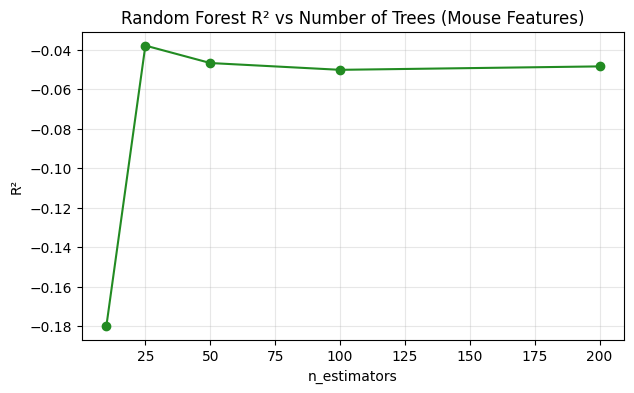

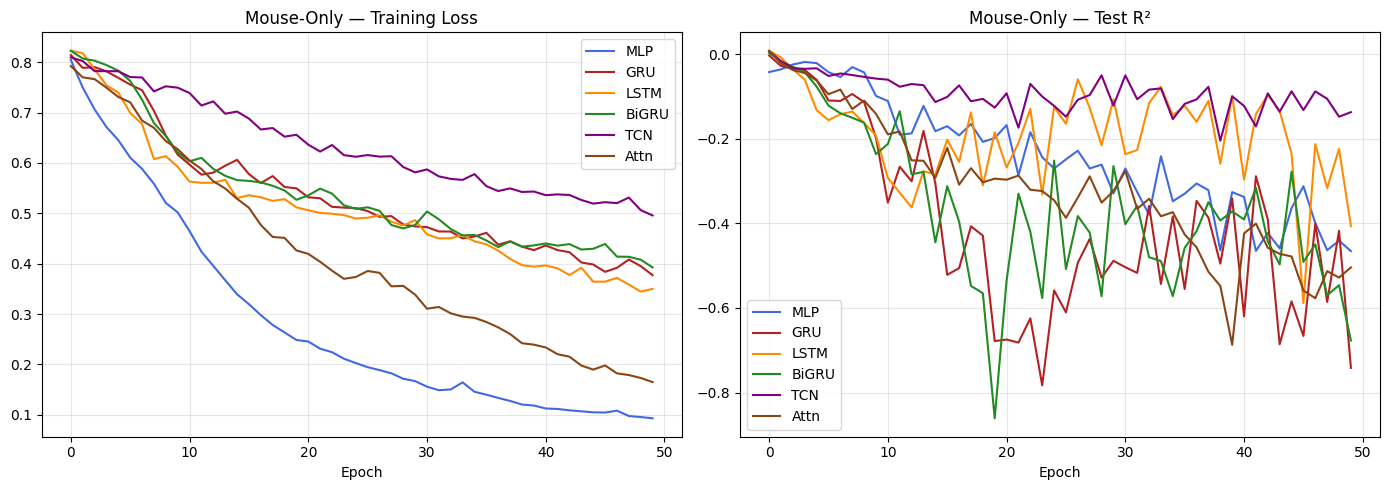

In [55]:
n_ms = len(MOUSE_FEATURES)

# ─── Random Forest curve (trees vs R²) ───────────────────────────────────────
def rf_curve(X_tr, y_tr, X_te, y_te, tree_counts=(10, 25, 50, 100, 200)):
    """Train RF at multiple n_estimators and track test R²."""
    Xtr_flat = X_tr.reshape(len(X_tr), -1)
    Xte_flat = X_te.reshape(len(X_te), -1)
    ytr_flat = y_tr.ravel()
    scores = []

    for n in tqdm(tree_counts, desc="RF"):
        rf = RandomForestRegressor(
            n_estimators=n, max_depth=15, min_samples_leaf=5,
            max_features="sqrt", n_jobs=-1, random_state=42
        )
        rf.fit(Xtr_flat, ytr_flat)
        scores.append(r2_score(y_te, rf.predict(Xte_flat)))

    return list(tree_counts), scores


print("\n🌲 Training Random Forest (mouse features)...")
rf_trees, rf_ms_scores = rf_curve(X_ms_tr, y_ms_tr, X_ms_te, y_ms_te)

# ─── Deep Learning Models ─────────────────────────────────────────────────────
ms_models = {
    "MLP"  : MLP(SEQ_LEN, n_ms, 1),
    "GRU"  : RecurrentModel(n_ms, 1, mode="GRU"),
    "LSTM" : RecurrentModel(n_ms, 1, mode="LSTM"),
    "BiGRU": RecurrentModel(n_ms, 1, mode="BiGRU"),
    "TCN"  : TCN(n_ms, 1),
    "Attn" : AttentionModel(n_ms, 1),
}

ms_histories = {}
for name, model in ms_models.items():
    print(f"\n🚀 Training {name} (mouse)")
    is_flat = (name == "MLP")
    ms_histories[name] = train_model(
        model, ms_loader, X_ms_te, y_ms_te, is_flat=is_flat
    )
    print(f"   Final R²: {ms_histories[name][1][-1]:.4f}")

# ─── Summary ──────────────────────────────────────────────────────────────────
print("\n📊 MOUSE-ONLY MODEL COMPARISON")
print(f"{'Model':<10}  {'Final R²':>10}")
print("-" * 25)
for name, (_, r2s) in ms_histories.items():
    print(f"{name:<10}  {r2s[-1]:>10.4f}")
print(f"{'RF (200)':<10}  {rf_ms_scores[-1]:>10.4f}")

# RF curve
plt.figure(figsize=(7, 4))
plt.plot(rf_trees, rf_ms_scores, marker="o", color="forestgreen")
plt.title("Random Forest R² vs Number of Trees (Mouse Features)")
plt.xlabel("n_estimators")
plt.ylabel("R²")
plt.grid(alpha=0.3)
plt.show()

plot_results(ms_histories, "Mouse-Only")

---
## 10. Biosignal-Based Model Comparison <a id='10'></a>

This section uses the **composite biosignal CogLoad** (`CogLoad_bio`) as the prediction target — a cleaner ground truth than the original labels since it was derived from physiologically grounded weights.

Feature correlation analysis is run **on the training set only** (no leakage) to select the top-K keyboard features most correlated with this target.

📊 Top keyboard features by |correlation| with CogLoad_bio:
inactivity_ratio        0.087537
typing_error_proxy      0.062979
burstiness              0.054763
speed_trend             0.052818
cognitive_load_proxy    0.052395
KSPC_std                0.048639
interaction_density     0.042235
latency_cv              0.028309
typing_speed_std        0.020529
key_jump                0.018063

🔥 Selected: ['inactivity_ratio', 'typing_error_proxy', 'burstiness', 'speed_trend', 'cognitive_load_proxy', 'KSPC_std', 'interaction_density', 'latency_cv', 'typing_speed_std', 'key_jump']


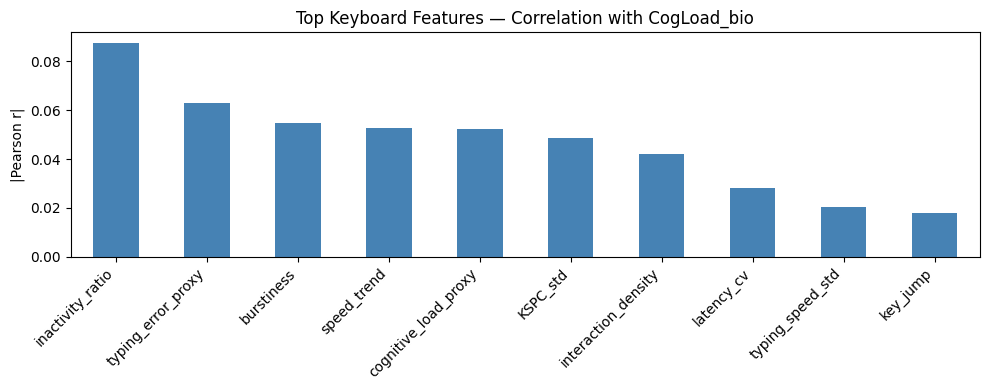

In [56]:
# ─── Correlation-Based Feature Selection (training set only) ──────────────────
TOP_K = 10

corr = train_df[KEYBOARD_FEATURES + ["CogLoad_bio"]].corr(numeric_only=True)["CogLoad_bio"]
corr = corr.drop("CogLoad_bio").abs().sort_values(ascending=False)

print("📊 Top keyboard features by |correlation| with CogLoad_bio:")
print(corr.head(TOP_K).to_string())

TOP_KEYBOARD = corr.head(TOP_K).index.tolist()
print(f"\n🔥 Selected: {TOP_KEYBOARD}")

# Rebuild sequences with selected features
X_top_tr, y_top_tr = build_sequences(train_df, TOP_KEYBOARD, ["CogLoad_bio"])
X_top_te, y_top_te = build_sequences(test_df,  TOP_KEYBOARD, ["CogLoad_bio"])

top_loader = make_loader(X_top_tr, y_top_tr)

# Visualize
plt.figure(figsize=(10, 4))
corr.head(TOP_K).plot(kind="bar", color="steelblue")
plt.title("Top Keyboard Features — Correlation with CogLoad_bio")
plt.ylabel("|Pearson r|")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 11. Multimodal Contrastive Alignment <a id='11'></a>

### Motivation

Biosignals are expensive to collect (require specialized hardware), but **mouse and keyboard signals are always available**. If we can align mouse behavior to biosignals in a shared latent space, we can later use mouse data alone to predict cognitive state.

### Method: Info-NCE Contrastive Loss

Two encoders (mouse and biosignal) learn to map the **same timestep** to similar latent vectors:

```
Mouse window  ──► MouseEncoder  ──► z_mouse
                                        ↕  (contrastive loss pulls these together)
Bio window    ──► BioEncoder    ──► z_bio
```

The **Info-NCE** loss treats each sample as its own class and pushes all non-matching pairs apart. Temperature (`τ = 0.07`) controls sharpness.

After training, `z_mouse` alone can be used to predict biosignal-derived cognitive state — enabling **non-invasive real-time inference**.

🚀 Training Multimodal Contrastive Alignment...


  3%|▎         | 2/60 [00:00<00:10,  5.74it/s]

   Epoch   0 | Contrastive Loss: 9.1196


 28%|██▊       | 17/60 [00:02<00:06,  6.87it/s]

   Epoch  15 | Contrastive Loss: 7.5036


 53%|█████▎    | 32/60 [00:04<00:04,  7.00it/s]

   Epoch  30 | Contrastive Loss: 6.9954


 78%|███████▊  | 47/60 [00:06<00:01,  6.86it/s]

   Epoch  45 | Contrastive Loss: 6.2805


100%|██████████| 60/60 [00:08<00:00,  6.89it/s]


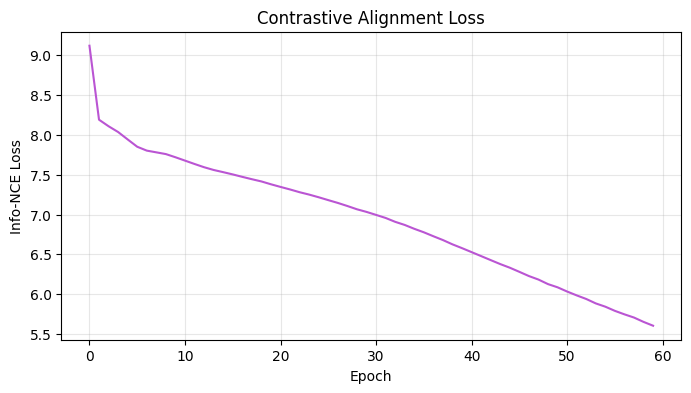


📌 Latent Alignment Score (cosine): 0.1420
🌲 Training Faster Random Forest Regression...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:   17.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  30 out of  30 | elapsed:    0.0s finished


🌲 Training completed in 17.94 seconds.
📌 RF Latent Regression R²: -0.2339

🧠 Cluster Quality (Silhouette): 0.2866
   Focus   (cluster 0): 29.86%
   Fatigue (cluster 1): 36.57%
   Overload(cluster 2): 33.57%


In [62]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

def info_nce_loss(z1, z2, temperature=0.07):
    """
    Symmetric Info-NCE contrastive loss.
    z1, z2: L2-normalized embeddings of shape (B, D)
    """
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = (z1 @ z2.T) / temperature      # (B, B) similarity matrix
    labels = torch.arange(len(z1), device=DEVICE)
    loss_a = F.cross_entropy(logits,   labels)  # z1 → z2
    loss_b = F.cross_entropy(logits.T, labels)  # z2 → z1
    return (loss_a + loss_b) / 2


# ─── Encoders ────────────────────────────────────────────────────────────────
n_bio = len(BIO_FEATURES)
# Assuming n_ms, LATENT_DIM, DEVICE, SEQ_LEN, TCN, AttentionModel, TransformerEncoder etc are defined above

mouse_encoder = TransformerEncoder(n_ms,  n_out=LATENT_DIM, normalize=True).to(DEVICE)
bio_encoder   = TransformerEncoder(n_bio, n_out=LATENT_DIM, normalize=True).to(DEVICE)

contrastive_opt = torch.optim.Adam(
    list(mouse_encoder.parameters()) + list(bio_encoder.parameters()),
    lr=1e-3
)

# Use first 3000 samples for efficiency
N_ALIGN = 3000
X_m_align = torch.tensor(X_ms_tr[:N_ALIGN],  dtype=torch.float32, device=DEVICE)
X_b_align = torch.tensor(X_bio_tr[:N_ALIGN], dtype=torch.float32, device=DEVICE)

print("🚀 Training Multimodal Contrastive Alignment...")
align_losses = []

for epoch in tqdm(range(60)):
    contrastive_opt.zero_grad()

    zm = mouse_encoder(X_m_align)
    zb = bio_encoder(X_b_align)

    loss = info_nce_loss(zm, zb)
    loss.backward()
    contrastive_opt.step()
    align_losses.append(loss.item())

    if epoch % 15 == 0:
        print(f"   Epoch {epoch:3d} | Contrastive Loss: {loss.item():.4f}")

plt.figure(figsize=(8, 4))
plt.plot(align_losses, color="mediumorchid")
plt.title("Contrastive Alignment Loss")
plt.xlabel("Epoch"); plt.ylabel("Info-NCE Loss")
plt.grid(alpha=0.3)
plt.show()

# ─── Extract Aligned Latent Representations ───────────────────────────────────
with torch.no_grad():
    Zm_train = mouse_encoder(torch.tensor(X_ms_tr, dtype=torch.float32, device=DEVICE)).cpu().numpy()
    Zm_test  = mouse_encoder(torch.tensor(X_ms_te, dtype=torch.float32, device=DEVICE)).cpu().numpy()
    Zb_train = bio_encoder(torch.tensor(X_bio_tr, dtype=torch.float32, device=DEVICE)).cpu().numpy()
    Zb_test  = bio_encoder(torch.tensor(X_bio_te, dtype=torch.float32, device=DEVICE)).cpu().numpy()

# Alignment metric: average cosine similarity between matching pairs
cos_align = float(np.mean(np.sum(Zm_test * Zb_test, axis=1)))
print(f"\n📌 Latent Alignment Score (cosine): {cos_align:.4f}")

# ─── Faster RF in latent space ────────────────────────────────────────────────
print("🌲 Training Faster Random Forest Regression...")
start_time = time.time()

# Reducing n_estimators (200 -> 100) and enabling verbose logging
rf_latent = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    n_jobs=-1,
    random_state=42,
    verbose=1 # Prints the progress of the tree building process
)
rf_latent.fit(Zm_train, Zb_train)

print(f"🌲 Training completed in {time.time() - start_time:.2f} seconds.")

latent_r2 = r2_score(Zb_test, rf_latent.predict(Zm_test), multioutput="variance_weighted")
print(f"📌 RF Latent Regression R²: {latent_r2:.4f}")

# ─── Cognitive State Clustering ───────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(Zm_train)
sil = silhouette_score(Zm_train, clusters)

print(f"\n🧠 Cluster Quality (Silhouette): {sil:.4f}")
print(f"   Focus   (cluster 0): {np.mean(clusters == 0):.2%}")
print(f"   Fatigue (cluster 1): {np.mean(clusters == 1):.2%}")
print(f"   Overload(cluster 2): {np.mean(clusters == 2):.2%}")

---
## 12. Teacher Model (Knowledge Distillation) <a id='12'></a>

### What is a Teacher Model?

The **Teacher** is a powerful model trained on all available signals (motor + biosignals) to predict cognitive load accurately. Its job is to **produce rich latent embeddings** that encode cognitive state.

These embeddings are then used to supervise the Student model (Section 13), which has access only to motor signals.

### Architecture
```
Input: [motor + biosignal] → LSTM (128 hidden) → Embedding (64-d) → Output (CogLoad, Stress, Unfocus)
```

The **embedding** layer is what the Student will learn to imitate.

In [58]:
TEACHER_MOTOR_FEATURES = [
    "typing_speed", "IKI", "burstiness", "interaction_density",
    "mouse_velocity", "mouse_energy", "mouse_entropy",
]

TEACHER_BIO_FEATURES = [
    "z_HR", "z_RMSSD", "z_EDA", "z_EEG", "z_FNIRS", "z_RESP", "ACC_energy",
]

TEACHER_ALL = TEACHER_MOTOR_FEATURES + TEACHER_BIO_FEATURES
TEACHER_WINDOW = 40


class CognitiveDataset(Dataset):
    """Dataset that builds sliding-window sequences from a DataFrame."""
    def __init__(self, df, features, targets, window):
        df = df.dropna(subset=features + targets).reset_index(drop=True)

        X = df[features].astype(np.float32).values
        y = df[targets].astype(np.float32).values

        self.scaler = StandardScaler()
        X = self.scaler.fit_transform(X)

        seqs, labs = [], []
        for i in range(window, len(X)):
            seqs.append(X[i - window : i])
            labs.append(y[i])

        self.X = torch.tensor(np.array(seqs), dtype=torch.float32)
        self.y = torch.tensor(np.array(labs), dtype=torch.float32)

    def __len__(self):              return len(self.X)
    def __getitem__(self, idx):     return self.X[idx], self.y[idx]


class TeacherModel(nn.Module):
    """
    2-layer LSTM encoder → 64-d cognitive embedding → 3-target head.
    The embedding is the distillation target for the Student.
    """
    def __init__(self, d_in):
        super().__init__()
        self.encoder   = nn.LSTM(d_in, 128, num_layers=2, batch_first=True)
        self.embedding = nn.Sequential(nn.Linear(128, LATENT_DIM), nn.ReLU(), nn.Dropout(0.2))
        self.head      = nn.Sequential(nn.Linear(LATENT_DIM, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z = self.embedding(h[-1])   # last layer hidden state
        return z, self.head(z)       # (embedding, predictions)


def train_teacher(df):
    dataset = CognitiveDataset(df, TEACHER_ALL, TARGETS, TEACHER_WINDOW)
    loader  = DataLoader(dataset, batch_size=256, shuffle=True)

    model     = TeacherModel(len(TEACHER_ALL)).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn   = nn.MSELoss()

    print("🚀 Training Teacher Model")
    for epoch in range(EPOCHS_TCH):
        model.train()
        total = 0
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            _, pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            total += loss.item()
        print(f"   Epoch {epoch+1:2d}/{EPOCHS_TCH} | Loss: {total:.4f}")

    # Extract all embeddings (used as Student targets)
    model.eval()
    all_z = []
    with torch.no_grad():
        for X, _ in loader:
            z, _ = model(X.to(DEVICE))
            all_z.append(z.cpu().numpy())
    teacher_z = np.vstack(all_z)

    # Save artifacts
    save_dir = Path("V2/models")
    save_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), save_dir / "teacher_model.pt")
    joblib.dump(dataset.scaler,    save_dir / "teacher_scaler.joblib")
    np.save(save_dir / "teacher_embeddings.npy", teacher_z)

    print(f"\n✅ Teacher saved — embedding shape: {teacher_z.shape}")
    return model, teacher_z, dataset.scaler


teacher_model, teacher_z, teacher_scaler = train_teacher(df)

🚀 Training Teacher Model
   Epoch  1/20 | Loss: 12.4840
   Epoch  2/20 | Loss: 2.3926
   Epoch  3/20 | Loss: 1.4835
   Epoch  4/20 | Loss: 0.9422
   Epoch  5/20 | Loss: 0.5991
   Epoch  6/20 | Loss: 0.5012
   Epoch  7/20 | Loss: 0.4869
   Epoch  8/20 | Loss: 0.4263
   Epoch  9/20 | Loss: 0.4191
   Epoch 10/20 | Loss: 0.3828
   Epoch 11/20 | Loss: 0.3727
   Epoch 12/20 | Loss: 0.3605
   Epoch 13/20 | Loss: 0.3475
   Epoch 14/20 | Loss: 0.3057
   Epoch 15/20 | Loss: 0.3039
   Epoch 16/20 | Loss: 0.2988
   Epoch 17/20 | Loss: 0.2815
   Epoch 18/20 | Loss: 0.2568
   Epoch 19/20 | Loss: 0.2423
   Epoch 20/20 | Loss: 0.2632

✅ Teacher saved — embedding shape: (9608, 64)


---
## 13. Student Model (Motor-Only Inference) <a id='13'></a>

### What is Knowledge Distillation?

The Student is trained to **mimic the Teacher's latent embedding** using only motor signals (keyboard + mouse). This is called **knowledge distillation**.

```
Teacher: [motor + bio] → z_teacher  (64-d)
Student: [motor only]  → z_student  (64-d)  ← trained to match z_teacher
```

### Why not just train the Student directly on labels?

Labels (`CogLoad`, `Stress`, `Unfocus`) are noisy. The Teacher's embedding is a **richer, smoother supervision signal** because it encodes patterns learned from both modalities.

### Loss: Cosine Distillation

```
L = 1 - cos(z_student, z_teacher)
```

This focuses on **direction** rather than magnitude, which is more stable and produces better-structured latent spaces.

🚀 Training Student (Cosine Distillation)
   Epoch  1/30 | Loss: 14.0075
   Epoch  2/30 | Loss: 12.0287
   Epoch  3/30 | Loss: 12.0223
   Epoch  4/30 | Loss: 12.0273
   Epoch  5/30 | Loss: 12.0032
   Epoch  6/30 | Loss: 12.0096
   Epoch  7/30 | Loss: 12.0150
   Epoch  8/30 | Loss: 12.0237
   Epoch  9/30 | Loss: 12.0081
   Epoch 10/30 | Loss: 11.9948
   Epoch 11/30 | Loss: 11.9981
   Epoch 12/30 | Loss: 11.9874
   Epoch 13/30 | Loss: 11.9908
   Epoch 14/30 | Loss: 11.9939
   Epoch 15/30 | Loss: 11.9780
   Epoch 16/30 | Loss: 11.9734
   Epoch 17/30 | Loss: 11.9522
   Epoch 18/30 | Loss: 11.9640
   Epoch 19/30 | Loss: 11.9580
   Epoch 20/30 | Loss: 11.9402
   Epoch 21/30 | Loss: 11.9311
   Epoch 22/30 | Loss: 11.9212
   Epoch 23/30 | Loss: 11.9164
   Epoch 24/30 | Loss: 11.9034
   Epoch 25/30 | Loss: 11.8895
   Epoch 26/30 | Loss: 11.8809
   Epoch 27/30 | Loss: 11.8471
   Epoch 28/30 | Loss: 11.8520
   Epoch 29/30 | Loss: 11.8321
   Epoch 30/30 | Loss: 11.8008


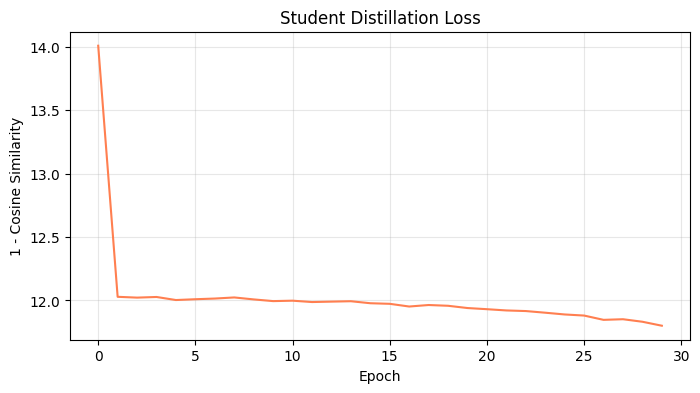


✅ Student model saved


In [59]:
class StudentModel(nn.Module):
    """
    Bidirectional 2-layer LSTM that maps motor-only sequences to the
    Teacher's 64-d cognitive embedding space.
    """
    def __init__(self, d_in):
        super().__init__()
        self.encoder = nn.LSTM(d_in, 128, num_layers=2, batch_first=True, bidirectional=True)
        self.proj    = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, LATENT_DIM),
        )

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        h = torch.cat([h[-2], h[-1]], dim=1)   # concat fwd + bwd last layers
        z = self.proj(h)
        return torch.tanh(z)                   # bounded latent space for stability


def cosine_distillation_loss(z_student, z_teacher):
    """1 - mean cosine similarity between student and teacher embeddings."""
    z_s = F.normalize(z_student, dim=1)
    z_t = F.normalize(z_teacher, dim=1)
    return 1 - (z_s * z_t).sum(dim=1).mean()


class StudentDataset(Dataset):
    """Pairs motor sequences with Teacher embeddings."""
    def __init__(self, df, motor_features, teacher_z, window):
        df = df.dropna(subset=motor_features).reset_index(drop=True)

        X = df[motor_features].astype(np.float32).values
        self.scaler = StandardScaler()
        X = self.scaler.fit_transform(X)

        seqs = [X[i - window : i] for i in range(window, len(X))]
        self.X = torch.tensor(np.array(seqs), dtype=torch.float32)
        self.y = torch.tensor(teacher_z[:len(self.X)], dtype=torch.float32)

    def __len__(self):              return len(self.X)
    def __getitem__(self, idx):     return self.X[idx], self.y[idx]


def train_student(df, teacher_z_path="V2/models/teacher_embeddings.npy"):
    teacher_z = np.load(teacher_z_path)

    dataset = StudentDataset(df, TEACHER_MOTOR_FEATURES, teacher_z, TEACHER_WINDOW)
    loader  = DataLoader(dataset, batch_size=256, shuffle=True)

    model     = StudentModel(len(TEACHER_MOTOR_FEATURES)).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    print("🚀 Training Student (Cosine Distillation)")
    student_losses = []

    for epoch in range(EPOCHS_STU):
        model.train()
        total = 0
        for X, z_t in loader:
            X, z_t = X.to(DEVICE), z_t.to(DEVICE)
            optimizer.zero_grad()
            z_s = model(X)
            loss = cosine_distillation_loss(z_s, z_t)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()
            total += loss.item()
        student_losses.append(total)
        print(f"   Epoch {epoch+1:2d}/{EPOCHS_STU} | Loss: {total:.4f}")

    save_dir = Path("V2/models")
    torch.save(model.state_dict(), save_dir / "student_model.pt")
    joblib.dump(dataset.scaler,    save_dir / "student_scaler.joblib")

    plt.figure(figsize=(8, 4))
    plt.plot(student_losses, color="coral")
    plt.title("Student Distillation Loss")
    plt.xlabel("Epoch"); plt.ylabel("1 - Cosine Similarity")
    plt.grid(alpha=0.3)
    plt.show()

    print("\n✅ Student model saved")
    return model


student_model = train_student(df)

---
## 📊 Final Results Summary

This cell collects and displays the final R² scores for all experiments in a single comparison chart.


  Model                            R²
  [KB] RF                      0.0175
  [MS] RF                     -0.0484
  [MS] TCN                    -0.1370
  [Multi] Align R²            -0.2339
  [MS] LSTM                   -0.4066
  [MS] MLP                    -0.4656
  [MS] Attn                   -0.5041
  [MS] BiGRU                  -0.6770
  [MS] GRU                    -0.7417
  [KB] MLP                    -1.0000
  [KB] RNN                    -1.0000
  [KB] GRU                    -1.0000
  [KB] LSTM                   -1.0000
  [KB] BiGRU                  -1.0000
  [KB] TCN                    -1.0000
  [KB] Attn                   -1.0000


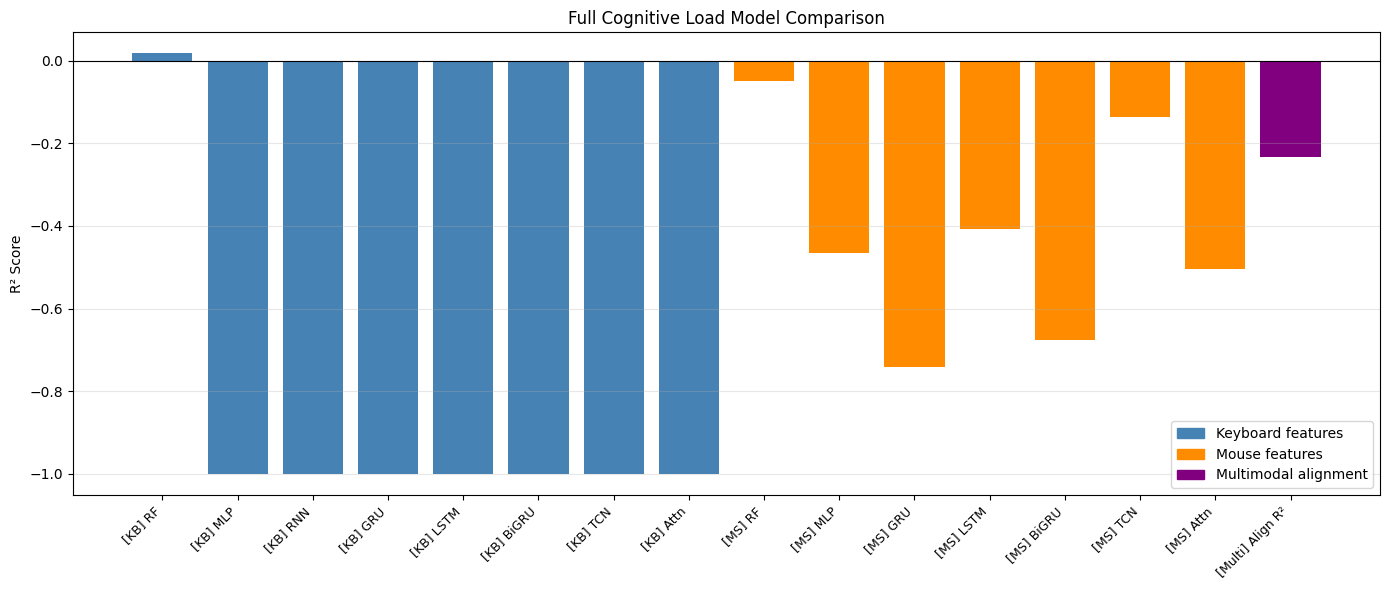

In [63]:
# Collect all final R² scores
summary = {
    "[KB] RF": rf_kb_r2,
    **{f"[KB] {k}": v[1][-1] for k, v in kb_histories.items()},
    "[MS] RF": rf_ms_scores[-1],
    **{f"[MS] {k}": v[1][-1] for k, v in ms_histories.items()},
    "[Multi] Align R²": latent_r2,
}

print("\n" + "=" * 45)
print(f"  {'Model':<25}  {'R²':>8}")
print("=" * 45)
for name, score in sorted(summary.items(), key=lambda x: -x[1]):
    print(f"  {name:<25}  {score:>8.4f}")
print("=" * 45)

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
names  = list(summary.keys())
scores = list(summary.values())
colors = ["steelblue" if "KB" in n else "darkorange" if "MS" in n else "purple" for n in names]

ax.bar(range(len(names)), scores, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("R² Score")
ax.set_title("Full Cognitive Load Model Comparison")
ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color="steelblue",  label="Keyboard features"),
        plt.Rectangle((0,0),1,1, color="darkorange", label="Mouse features"),
        plt.Rectangle((0,0),1,1, color="purple",     label="Multimodal alignment"),
    ],
    loc="lower right"
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()